# Descritization in Machine Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading dataset

In [11]:
df = pd.read_csv('E:/Dataset/titanic-Dataset.csv', usecols=['Age','Fare','Survived'])

In [18]:
df.dropna(inplace=True)  # 'row' where any NA or None value will remove the whole row
df.sample(5)

,Survived,Age,Fare
541,0,9.0,31.2750
282,0,16.0,9.5000
395,0,22.0,7.7958
817,0,31.0,37.0042
486,1,35.0,90.0000


In [15]:
df.shape

(714, 3)

### Splitting dataset

In [19]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [32]:
from sklearn.model_selection import train_test_split

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [24]:
x_train.shape

(571, 2)

### Finding accuracy score before Discretization

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

In [25]:
dtc = DecisionTreeClassifier()

In [27]:
dtc.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred = dtc.predict(x_test)

In [29]:
accuracy_score(y_test, y_pred)

0.6643356643356644

In [31]:
cross_val_score(dtc, x, y, cv=10, scoring='accuracy').mean()

np.float64(0.6372848200312988)

### Discretize our data

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [39]:
kbin_age = KBinsDiscretizer(n_bins=5, strategy='kmeans', encode='ordinal')
kbin_fare = KBinsDiscretizer(n_bins=5, strategy='kmeans', encode='ordinal')

In [41]:
x_train.sample()

,Age,Fare
542,11.0,31.275


In [47]:
trf = ColumnTransformer([
    ('age', kbin_age, [0]),
    ('fare', kbin_fare, [1])
], remainder='passthrough')

In [48]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


#### Analyzing transformers

In [64]:
trf.transformers_  # Return a list

[('age', KBinsDiscretizer(encode='ordinal', strategy='kmeans'), [0]),
 ('fare', KBinsDiscretizer(encode='ordinal', strategy='kmeans'), [1])]

In [66]:
trf.named_transformers_ # Return a dictionary

{'age': KBinsDiscretizer(encode='ordinal', strategy='kmeans'),
 'fare': KBinsDiscretizer(encode='ordinal', strategy='kmeans')}

In [72]:
trf.named_transformers_['age'].n_bins_  # How many bins

array([5])

In [73]:
trf.named_transformers_['age'].bin_edges_  # How the bins are actually shaped

array([array([ 0.42      , 13.29123816, 27.03552379, 39.37696746, 54.20867647,
              80.        ])                                                   ],
      dtype=object)

In [90]:
trf.named_transformers_['age'].bin_edges_[0]

array([ 0.42      , 13.29123816, 27.03552379, 39.37696746, 54.20867647,
       80.        ])

In [94]:
x_train_trf

array([[1., 0.],
       [1., 0.],
       [2., 0.],
       ...,
       [1., 0.],
       [1., 1.],
       [1., 0.]], shape=(571, 2))

In [97]:
output = pd.DataFrame({
    'age': x_train['Age'],
    'age_trf': x_train_trf[:,0],
    'fare': x_train['Fare'],
    'fare_trf': x_train_trf[:,1]
})

In [100]:
output['age_label'] = pd.cut(x=x_train['Age'], bins=trf.named_transformers_['age'].bin_edges_[0].tolist())
output['fare_label'] = pd.cut(x=x_train['Fare'], bins=trf.named_transformers_['fare'].bin_edges_[0].tolist())

In [101]:
output.head()

,age,age_trf,fare,fare_trf,age_label,fare_label
830,15.0,1.0,14.4542,0.0,"(13.291, 27.036]","(0.0, 41.617]"
565,24.0,1.0,24.1500,0.0,"(13.291, 27.036]","(0.0, 41.617]"
148,36.5,2.0,26.0000,0.0,"(27.036, 39.377]","(0.0, 41.617]"
105,28.0,2.0,7.8958,0.0,"(27.036, 39.377]","(0.0, 41.617]"
289,22.0,1.0,7.7500,0.0,"(13.291, 27.036]","(0.0, 41.617]"


### Finding accuracy score after Discretization

In [113]:
dtc2 = DecisionTreeClassifier()

In [114]:
dtc.fit(x_train_trf, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [115]:
y_pred = dtc.predict(x_test)

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [116]:
accuracy_score(y_test, y_pred)

0.6363636363636364

In [117]:
x_trf = trf.fit_transform(x)
cross_val_score(dtc2, x_trf, y, cv=10, scoring='accuracy').mean()

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


np.float64(0.6723982785602504)

### Define a function for accuracy score for different bins, and strategy

In [118]:
import seaborn as sns

In [147]:
def Discretizer(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, strategy=strategy, encode='ordinal')
    kbin_fare = KBinsDiscretizer(n_bins=bins, strategy=strategy, encode='ordinal')

    trf = ColumnTransformer([
        ('age', kbin_age, [0]),
        ('fare', kbin_fare, [1])
    ])
    x_trf = trf.fit_transform(x)
    print("Accuracy score :", cross_val_score(DecisionTreeClassifier(), x_trf, y, cv=10, scoring='accuracy').mean())

    fig, axes = plt.subplots(2,2, figsize=(10,7))
    
    sns.histplot(x_train['Age'], ax=axes[0][0])
    axes[0][0].set_title("Age before Discretization")
    sns.histplot(x_trf[:,0], color='red', ax=axes[0][1])
    axes[0][1].set_title("Age after Discretization")
    
    sns.histplot(x_train['Fare'], ax=axes[1][0])
    axes[1][0].set_title("Fare before Discretization")
    sns.histplot(x_trf[:,0],color='red', ax=axes[1][1])
    axes[1][1].set_title("Fare after Discretization")

    plt.tight_layout()
    plt.show()

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Accuracy score : 0.682140062597809


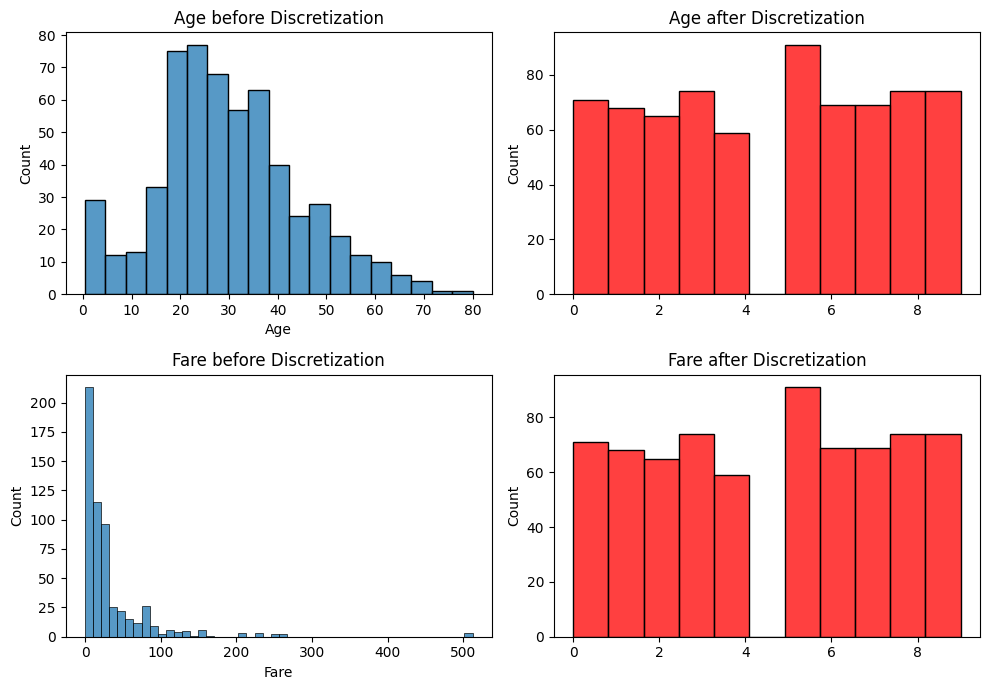

In [150]:
Discretizer(10, 'quantile')

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Accuracy score : 0.6613458528951487


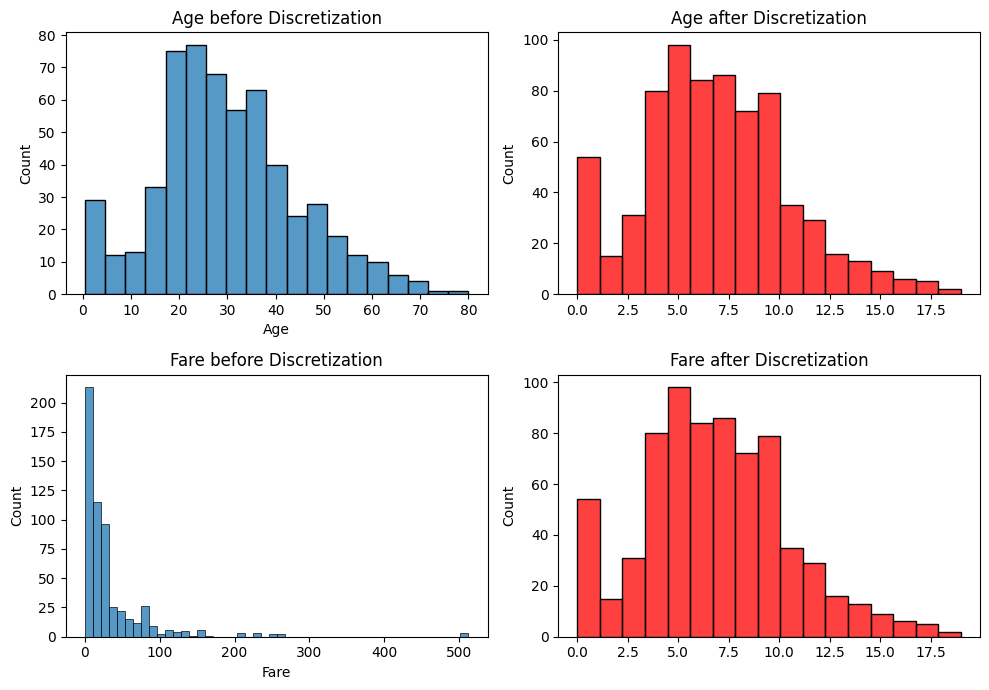

In [151]:
Discretizer(20, 'kmeans')

Accuracy score : 0.6541275430359936


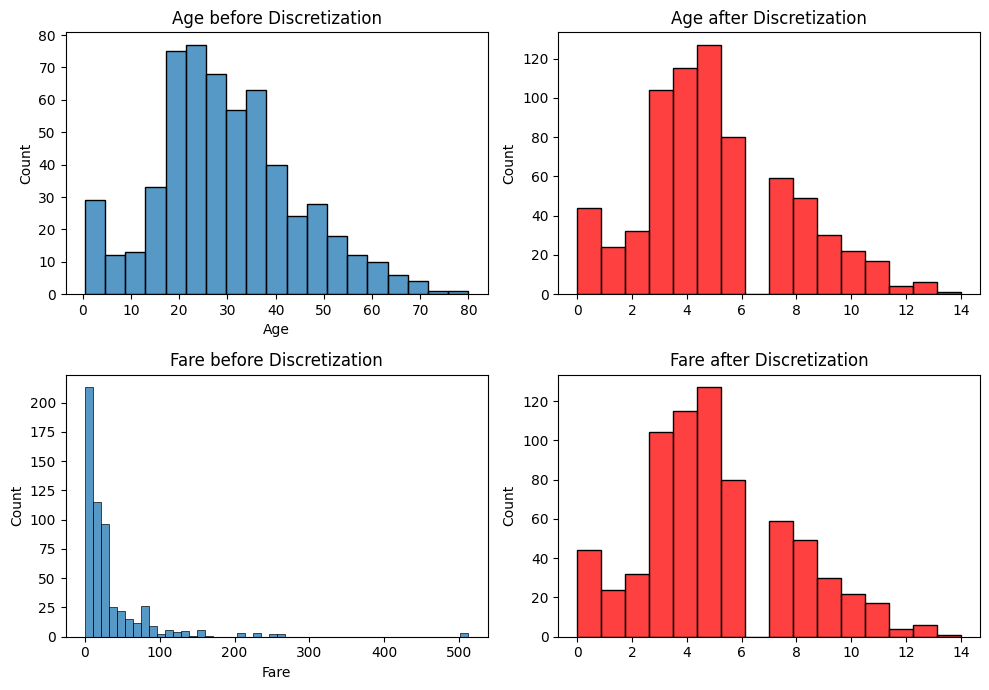

In [152]:
Discretizer(15, 'uniform')